<a href="https://colab.research.google.com/github/navros-fabian/Challenge-Alura_Store-Latam/blob/main/TELECOM_X_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tarjeta 1: Extracción de Datos

Necesitamos importar los datos de la API de Telecom X. Estos datos están disponibles en formato JSON y contienen información esencial sobre los clientes, incluyendo datos demográficos, tipo de servicio contratado y estado de evasión.

🔗 https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json


In [ ]:

import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# URL de la API proporcionada por el challenge
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

print("🔄 Iniciando extracción de datos desde la API...")

try:
    # 1. Obtener los datos de la API
    respuesta = requests.get(url, timeout=20)
    respuesta.raise_for_status()
    datos_json = respuesta.json()

    # 2. Convertir a DataFrame
    # Usamos json_normalize() porque la estructura JSON es anidada
    # Esto separa 'customer', 'phone', 'account', etc. en columnas individuales
    df = pd.json_normalize(datos_json)

    print("✅ Extracción exitosa.")
    print(f"📊 El dataset tiene {df.shape[0]} filas y {df.shape[1]} columnas.")
    print("\n📋 Primeras 5 filas del dataset:")
    display(df.head())

except Exception as e:
    print(f"❌ Error al extraer los datos: {e}")

🔄 Iniciando extracción de datos desde la API...
✅ Extracción exitosa.
📊 El dataset tiene 7267 filas y 21 columnas.

📋 Primeras 5 filas del dataset:


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


# Tarjeta 2: Conoce el Conjunto de Datos

Hemos extraído los datos, es fundamental comprender la estructura del dataset y el significado de sus columnas. Esta etapa nos ayudará a identificar qué variables son más relevantes para el análisis de evasión de clientes.

In [ ]:
# --- Exploración general del dataset ---
print("=" * 60)
print("📋 INFORMACIÓN GENERAL DEL DATASET")
print("=" * 60)
df.info()

print("\n" + "=" * 60)
print("🔢 TIPOS DE DATOS POR COLUMNA")
print("=" * 60)
print(df.dtypes)

print("\n" + "=" * 60)
print("🔍 VERIFICACIÓN DE DUPLICADOS")
print("=" * 60)
print(f"Filas duplicadas encontradas: {df.duplicated().sum()}")

📋 INFORMACIÓN GENERAL DEL DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechS

In [ ]:
# --- Diccionario de Datos ---
# Descripción de las columnas más relevantes para el análisis

diccionario = {
    'Columna': [
        'customerID', 'Churn',
        'customer.gender', 'customer.SeniorCitizen', 'customer.Partner',
        'customer.Dependents', 'customer.tenure',
        'phone.PhoneService', 'phone.MultipleLines',
        'internet.InternetService', 'internet.OnlineSecurity',
        'internet.TechSupport', 'internet.StreamingTV',
        'account.Contract', 'account.PaperlessBilling',
        'account.PaymentMethod', 'account.Charges.Monthly',
        'account.Charges.Total'
    ],
    'Descripción': [
        'Identificador único del cliente', 'Si el cliente abandonó el servicio (Yes/No)',
        'Género del cliente (Male/Female)', 'Si el cliente es adulto mayor (1/0)',
        'Si el cliente tiene pareja (Yes/No)', 'Si el cliente tiene dependientes (Yes/No)',
        'Meses que el cliente lleva con la empresa',
        'Si tiene servicio telefónico (Yes/No)', 'Si tiene múltiples líneas (Yes/No)',
        'Tipo de servicio de internet (DSL/Fiber/No)',
        'Si tiene seguridad online (Yes/No)', 'Si tiene soporte técnico (Yes/No)',
        'Si tiene TV en streaming (Yes/No)',
        'Tipo de contrato (Month-to-month/One year/Two year)',
        'Si usa facturación sin papel (Yes/No)',
        'Método de pago del cliente',
        'Cargo mensual actual del cliente (USD)',
        'Total cobrado al cliente durante su permanencia (USD)'
    ]
}

df_diccionario = pd.DataFrame(diccionario)
print("📖 DICCIONARIO DE DATOS")
display(df_diccionario)

📖 DICCIONARIO DE DATOS


,Columna,Descripción
0,customerID,Identificador único del cliente
1,Churn,Si el cliente abandonó el servicio (Yes/No)
2,customer.gender,Género del cliente (Male/Female)
3,customer.SeniorCitizen,Si el cliente es adulto mayor (1/0)
4,customer.Partner,Si el cliente tiene pareja (Yes/No)
5,customer.Dependents,Si el cliente tiene dependientes (Yes/No)
6,customer.tenure,Meses que el cliente lleva con la empresa
7,phone.PhoneService,Si tiene servicio telefónico (Yes/No)
8,phone.MultipleLines,Si tiene múltiples líneas (Yes/No)
9,internet.InternetService,Tipo de servicio de internet (DSL/Fiber/No)


# Tarjeta 3: Comprobación de Incoherencias en los Datos

verificamos si hay problemas en los datos que puedan afectar el análisis. Prestamos atención a:

- Valores ausentes (NaN)
- Registros duplicados
- Errores de formato e inconsistencias en las categorías

In [ ]:
# --- Comprobación de valores nulos ---
print("=" * 60)
print("🔍 VALORES NULOS POR COLUMNA")
print("=" * 60)
nulos = df.isnull().sum().sort_values(ascending=False)
print(nulos[nulos > 0] if nulos.sum() > 0 else "✅ No se encontraron valores nulos")

print("\n" + "=" * 60)
print("🔍 VALORES ÚNICOS EN COLUMNAS CATEGÓRICAS CLAVE")
print("=" * 60)

columnas_clave = [
    'customer.gender', 'account.Contract',
    'account.PaymentMethod', 'Churn'
]

for col in columnas_clave:
    if col in df.columns:
        print(f"\n📌 Columna: '{col}'")
        print(df[col].value_counts(dropna=False))

print("\n" + "=" * 60)
print("🔍 TIPOS MIXTOS O STRINGS NUMÉRICOS (Charges.Total)")
print("=" * 60)
print(df['account.Charges.Total'].dtype)
print("Muestra de valores:", df['account.Charges.Total'].unique()[:10])

🔍 VALORES NULOS POR COLUMNA
✅ No se encontraron valores nulos

🔍 VALORES ÚNICOS EN COLUMNAS CATEGÓRICAS CLAVE

📌 Columna: 'customer.gender'
customer.gender
Male      3675
Female    3592
Name: count, dtype: int64

📌 Columna: 'account.Contract'
account.Contract
Month-to-month    4005
Two year          1743
One year          1519
Name: count, dtype: int64

📌 Columna: 'account.PaymentMethod'
account.PaymentMethod
Electronic check             2445
Mailed check                 1665
Bank transfer (automatic)    1589
Credit card (automatic)      1568
Name: count, dtype: int64

📌 Columna: 'Churn'
Churn
No     5174
Yes    1869
        224
Name: count, dtype: int64

🔍 TIPOS MIXTOS O STRINGS NUMÉRICOS (Charges.Total)
object
Muestra de valores: ['593.3' '542.4' '280.85' '1237.85' '267.4' '571.45' '7904.25' '5377.8'
 '340.35' '5957.9']


# Tarjeta 4: Manejo de Inconsistencias

Ahora que hemos identificado las inconsistencias, aplicamos las correcciones necesarias para asegurarnos de que los datos estén completos y coherentes

In [ ]:
# --- Manejo de Inconsistencias ---

# 1. Convertir columnas de cargos a tipo numérico
# (pueden venir como string vacío '' o con espacios)
df['account.Charges.Total'] = pd.to_numeric(df['account.Charges.Total'], errors='coerce')
df['account.Charges.Monthly'] = pd.to_numeric(df['account.Charges.Monthly'], errors='coerce')

# 2. Verificar cuántos nulos aparecieron tras la conversión
nulos_total = df['account.Charges.Total'].isnull().sum()
nulos_monthly = df['account.Charges.Monthly'].isnull().sum()
print(f"🔢 Valores nulos en Charges.Total tras conversión: {nulos_total}")
print(f"🔢 Valores nulos en Charges.Monthly tras conversión: {nulos_monthly}")

# 3. Rellenar nulos con 0 (clientes nuevos sin historial de pagos)
df['account.Charges.Total'] = df['account.Charges.Total'].fillna(0)
df['account.Charges.Monthly'] = df['account.Charges.Monthly'].fillna(0)

# 4. Eliminar espacios en blanco en columnas de texto
df = df.apply(lambda x: x.str.strip() if x.dtype == 'object' else x)

# 5. Verificar columna Churn: limpiar valores inconsistentes si los hay
print(f"\n📊 Valores únicos en 'Churn' tras limpieza: {df['Churn'].unique()}")

# 6. Eliminar duplicados si existen
before = df.shape[0]
df = df.drop_duplicates()
after = df.shape[0]
print(f"\n🗑️  Duplicados eliminados: {before - after}")
print("\n✅ Manejo de inconsistencias completado.")

🔢 Valores nulos en Charges.Total tras conversión: 11
🔢 Valores nulos en Charges.Monthly tras conversión: 0

📊 Valores únicos en 'Churn' tras limpieza: ['No' 'Yes' '']

🗑️  Duplicados eliminados: 0

✅ Manejo de inconsistencias completado.


# Tarjeta 5: Columna de Cuentas Diarias

Ahora que los datos están limpios, creamos la columna Cuentas_Diarias. Utilizamos la facturación mensual para calcular el valor diario, lo que proporciona una visión más detallada del comportamiento de los clientes a lo largo del tiempo.

In [ ]:
# --- Feature Engineering: Columna Cuentas_Diarias ---
# Cálculo: cargo mensual dividido entre 30 días

df['Cuentas_Diarias'] = (df['account.Charges.Monthly'] / 30).round(2)

print("✅ Columna 'Cuentas_Diarias' creada exitosamente.")
print("\n📊 Estadísticas de la nueva columna:")
print(df['Cuentas_Diarias'].describe().round(2))
print("\n📋 Muestra de valores:")
print(df[['account.Charges.Monthly', 'Cuentas_Diarias']].head(10))

✅ Columna 'Cuentas_Diarias' creada exitosamente.

📊 Estadísticas de la nueva columna:
count    7267.00
mean        2.16
std         1.00
min         0.61
25%         1.18
50%         2.34
75%         3.00
max         3.96
Name: Cuentas_Diarias, dtype: float64

📋 Muestra de valores:
   account.Charges.Monthly  Cuentas_Diarias
0                    65.60             2.19
1                    59.90             2.00
2                    73.90             2.46
3                    98.00             3.27
4                    83.90             2.80
5                    69.40             2.31
6                   109.70             3.66
7                    84.65             2.82
8                    48.20             1.61
9                    90.45             3.02


# Tarjeta 6: Estandarización y Transformación de Datos (Recomendado)

La estandarización y transformación de datos busca hacer que la información sea más consistente, comprensible y adecuada para el análisis.

In [ ]:
# --- Estandarización y Transformación ---

# 1. Diccionario de renombrado de columnas (inglés → español)
diccionario_nombres = {
    'customerID':                   'ID_Cliente',
    'Churn':                        'Evasion',
    'customer.gender':              'Genero',
    'customer.SeniorCitizen':       'Adulto_Mayor',
    'customer.Partner':             'Tiene_Pareja',
    'customer.Dependents':          'Tiene_Dependientes',
    'customer.tenure':              'Meses_Contrato',
    'phone.PhoneService':           'Servicio_Telefono',
    'phone.MultipleLines':          'Multiples_Lineas',
    'internet.InternetService':     'Tipo_Internet',
    'internet.OnlineSecurity':      'Seguridad_Online',
    'internet.OnlineBackup':        'Backup_Online',
    'internet.DeviceProtection':    'Proteccion_Dispositivo',
    'internet.TechSupport':         'Soporte_Tecnico',
    'internet.StreamingTV':         'Streaming_TV',
    'internet.StreamingMovies':     'Streaming_Peliculas',
    'account.Contract':             'Tipo_Contrato',
    'account.PaperlessBilling':     'Factura_Digital',
    'account.PaymentMethod':        'Metodo_Pago',
    'account.Charges.Monthly':      'Cargos_Mensuales',
    'account.Charges.Total':        'Cargos_Totales'
}

df_limpio = df.rename(columns=diccionario_nombres)

# 2. Convertir Evasión (Yes/No) → Binario (1/0)
df_limpio['Evasion_Binaria'] = df_limpio['Evasion'].map({'Yes': 1, 'No': 0}).fillna(-1)
# Verificar si hay valores no mapeados
if (df_limpio['Evasion_Binaria'] == -1).any():
    print("⚠️  Advertencia: Hay valores en 'Evasion' que no son 'Yes' o 'No'")
    print(f"Valores problemáticos: {df_limpio[df_limpio['Evasion_Binaria'] == -1]['Evasion'].unique()}")

print("✅ Datos estandarizados y traducidos.")

print(f"\n📊 Columnas en el dataset limpio: {df_limpio.shape[1]}")

print("\n📋 Vista previa del dataset transformado:")
display(df_limpio[['ID_Cliente', 'Evasion', 'Evasion_Binaria', 'Genero',
                   'Tipo_Contrato', 'Cargos_Mensuales', 'Cuentas_Diarias']].head())

⚠️  Advertencia: Hay valores en 'Evasion' que no son 'Yes' o 'No'
Valores problemáticos: ['']
✅ Datos estandarizados y traducidos.

📊 Columnas en el dataset limpio: 23

📋 Vista previa del dataset transformado:


,ID_Cliente,Evasion,Evasion_Binaria,Genero,Tipo_Contrato,Cargos_Mensuales,Cuentas_Diarias
0,0002-ORFBO,No,0.0,Female,One year,65.6,2.19
1,0003-MKNFE,No,0.0,Male,Month-to-month,59.9,2.00
2,0004-TLHLJ,Yes,1.0,Male,Month-to-month,73.9,2.46
3,0011-IGKFF,Yes,1.0,Male,Month-to-month,98.0,3.27
4,0013-EXCHZ,Yes,1.0,Female,Month-to-month,83.9,2.80


# Tarjeta 7: Análisis Descriptivo

Comenzamos con un análisis descriptivo de los datos, calculando métricas como media, mediana, desviación estándar y otras medidas que ayuden a comprender la distribución y el comportamiento de los clientes.

In [ ]:
# --- Análisis Descriptivo ---
print("=" * 60)
print("📊 ESTADÍSTICAS DESCRIPTIVAS — VARIABLES NUMÉRICAS")
print("=" * 60)

cols_numericas = ['Meses_Contrato', 'Cargos_Mensuales', 'Cargos_Totales', 'Cuentas_Diarias']
display(df_limpio[cols_numericas].describe().round(2))

print("\n" + "=" * 60)
print("📊 DISTRIBUCIÓN DE LA VARIABLE OBJETIVO: EVASIÓN")
print("=" * 60)
conteo_evasion = df_limpio['Evasion'].value_counts()
porcentaje_evasion = df_limpio['Evasion'].value_counts(normalize=True) * 100
resumen = pd.DataFrame({'Cantidad': conteo_evasion, 'Porcentaje (%)': porcentaje_evasion.round(2)})
print(resumen)
print(f"\n📌 Tasa de evasión total: {porcentaje_evasion['Yes']:.2f}%")

📊 ESTADÍSTICAS DESCRIPTIVAS — VARIABLES NUMÉRICAS


,Meses_Contrato,Cargos_Mensuales,Cargos_Totales,Cuentas_Diarias
count,7267.00,7267.00,7267.00,7267.00
mean,32.35,64.72,2277.18,2.16
std,24.57,30.13,2268.65,1.00
min,0.00,18.25,0.00,0.61
25%,9.00,35.42,396.20,1.18
50%,29.00,70.30,1389.20,2.34
75%,55.00,89.88,3778.52,3.00
max,72.00,118.75,8684.80,3.96



📊 DISTRIBUCIÓN DE LA VARIABLE OBJETIVO: EVASIÓN
         Cantidad  Porcentaje (%)
Evasion                          
No           5174           71.20
Yes          1869           25.72
              224            3.08

📌 Tasa de evasión total: 25.72%


# Tarjeta 8: Distribución de Evasión

En este paso, el objetivo es comprender cómo está distribuida la variable churn (evasión) entre los clientes. Utilizamos gráficos para visualizar la proporción de clientes que permanecieron y los que se dieron de baja.

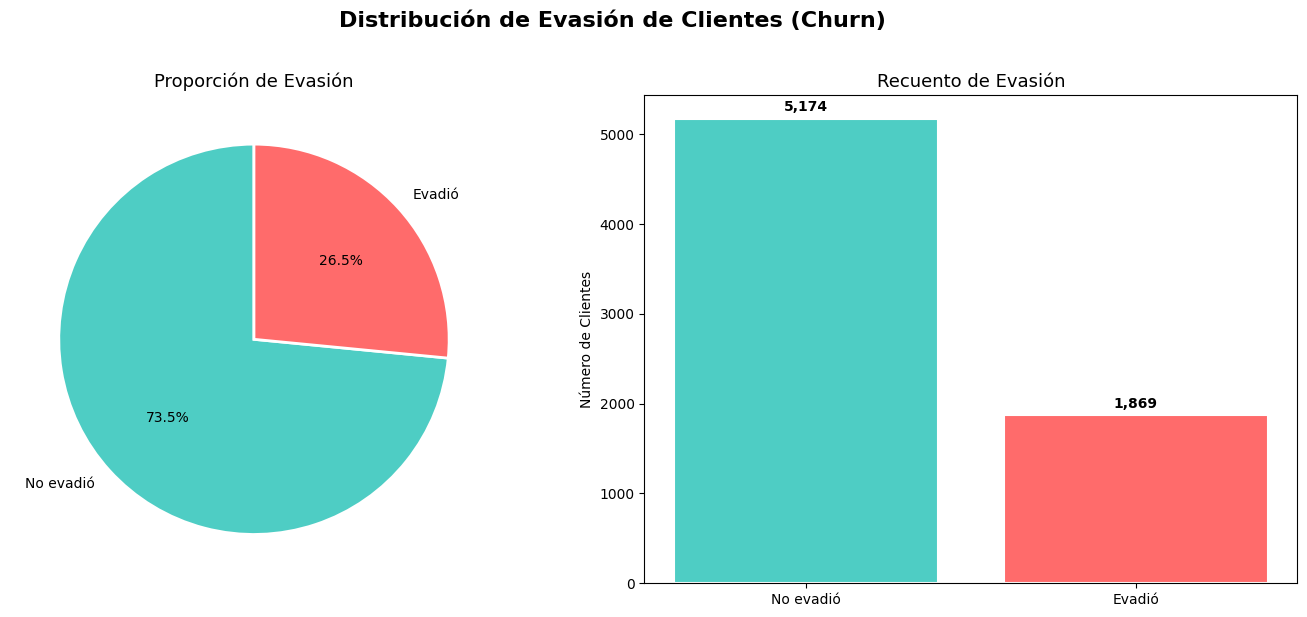


📌 De 7,043 clientes, 1,869 (26.5%) abandonaron el servicio.


In [ ]:
# --- Distribución de Evasión ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Distribución de Evasión de Clientes (Churn)', fontsize=16, fontweight='bold', y=1.02)

# Gráfico 1: Pie chart
colores = ['#4ECDC4', '#FF6B6B']
conteo = df_limpio['Evasion'].value_counts().reindex(['No', 'Yes'])  # ← Ordenar consistentemente
axes[0].pie(
    conteo,
    labels=['No evadió', 'Evadió'],
    autopct='%1.1f%%',
    colors=colores,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title('Proporción de Evasión', fontsize=13)

# Gráfico 2: Barras
bars = axes[1].bar(
    ['No evadió', 'Evadió'],
    conteo.values,
    color=colores,
    edgecolor='white',
    linewidth=1.5
)
axes[1].set_title('Recuento de Evasión', fontsize=13)
axes[1].set_ylabel('Número de Clientes')
for bar, val in zip(bars, conteo.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{val:,}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()
print(f"\n📌 De {conteo.sum():,} clientes, {conteo['Yes']:,} ({conteo['Yes']/conteo.sum()*100:.1f}%) abandonaron el servicio.")

# Tarjeta 9: Recuento de Evasión por Variables Categóricas
Exploramos cómo se distribuye la evasión según variables categóricas, como género, tipo de contrato y método de pago.

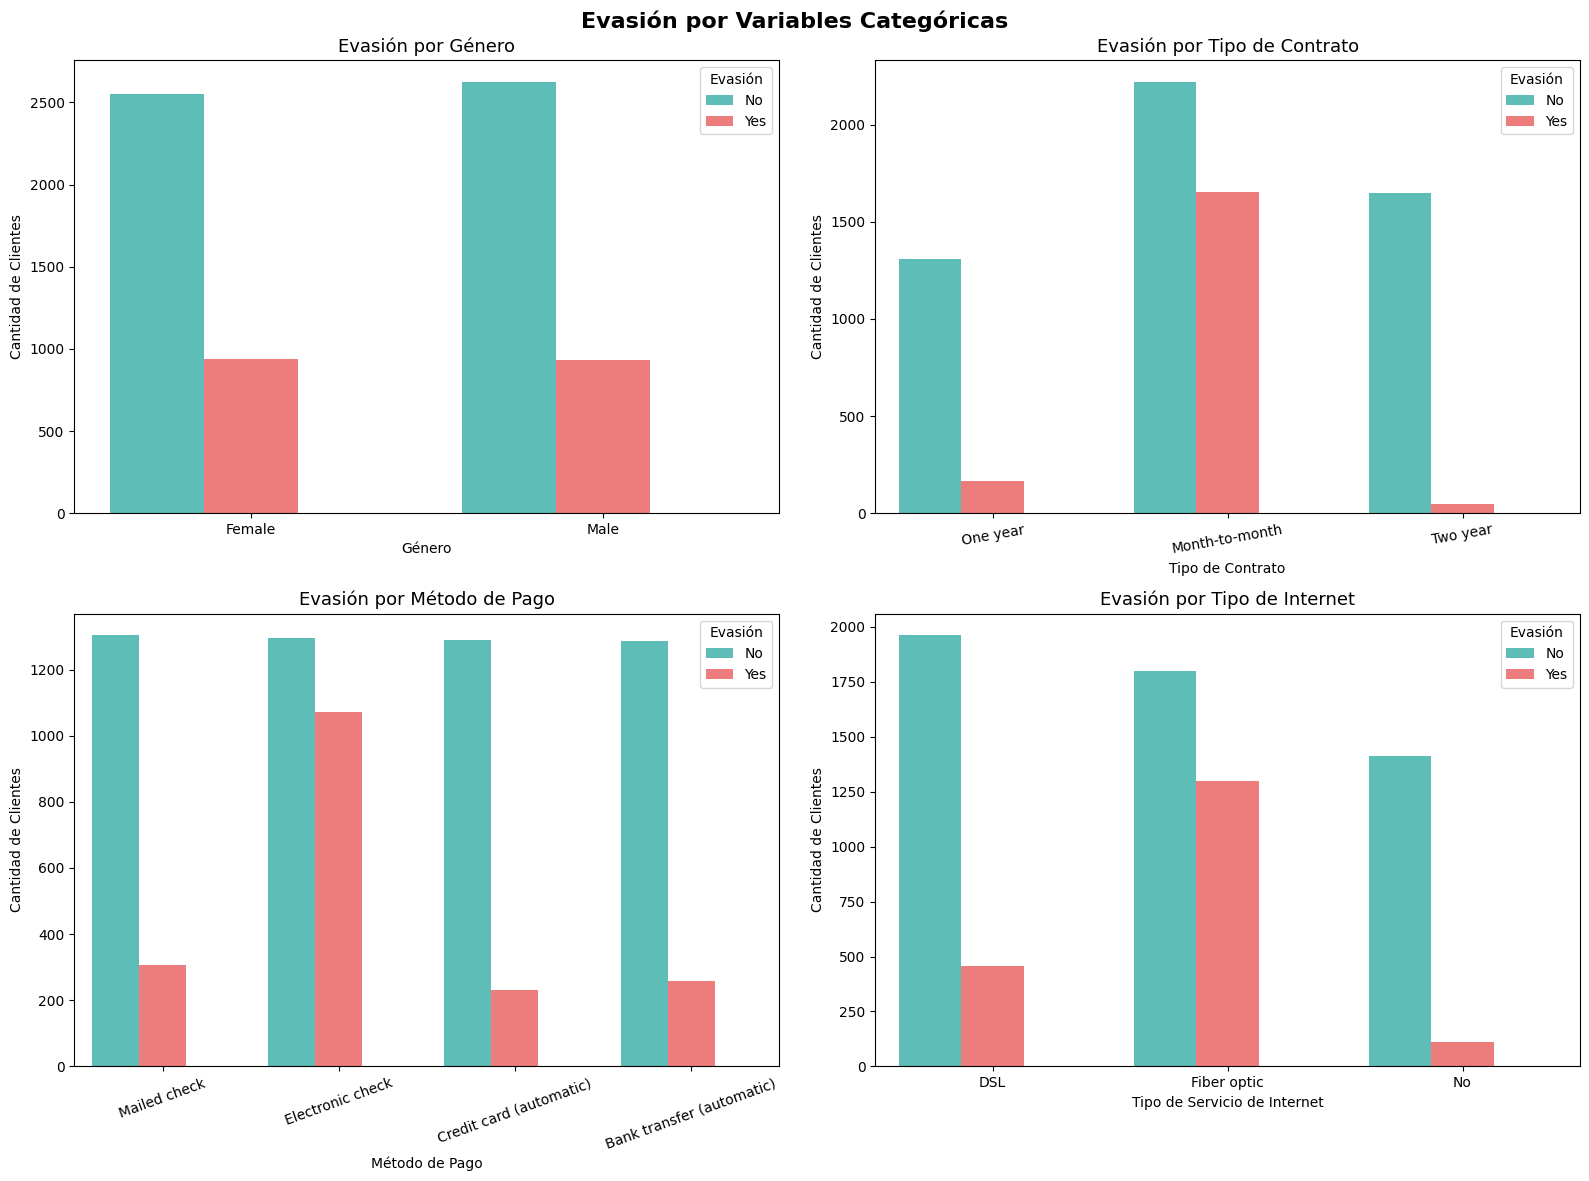

In [ ]:
# --- Evasión por Variables Categóricas ---
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Evasión por Variables Categóricas', fontsize=16, fontweight='bold')

paleta = {'Yes': '#FF6B6B', 'No': '#4ECDC4'}

# 1. Por Género
sns.countplot(x='Genero', hue='Evasion', data=df_limpio,
              palette=paleta, ax=axes[0, 0])
axes[0, 0].set_title('Evasión por Género', fontsize=13)
axes[0, 0].set_xlabel('Género')
axes[0, 0].set_ylabel('Cantidad de Clientes')
axes[0, 0].legend(title='Evasión')

# 2. Por Tipo de Contrato
sns.countplot(x='Tipo_Contrato', hue='Evasion', data=df_limpio,
              palette=paleta, ax=axes[0, 1])
axes[0, 1].set_title('Evasión por Tipo de Contrato', fontsize=13)
axes[0, 1].set_xlabel('Tipo de Contrato')
axes[0, 1].set_ylabel('Cantidad de Clientes')
axes[0, 1].tick_params(axis='x', rotation=10)
axes[0, 1].legend(title='Evasión')

# 3. Por Método de Pago
sns.countplot(x='Metodo_Pago', hue='Evasion', data=df_limpio,
              palette=paleta, ax=axes[1, 0])
axes[1, 0].set_title('Evasión por Método de Pago', fontsize=13)
axes[1, 0].set_xlabel('Método de Pago')
axes[1, 0].set_ylabel('Cantidad de Clientes')
axes[1, 0].tick_params(axis='x', rotation=20)
axes[1, 0].legend(title='Evasión')

# 4. Por Tipo de Internet
sns.countplot(x='Tipo_Internet', hue='Evasion', data=df_limpio,
              palette=paleta, ax=axes[1, 1])
axes[1, 1].set_title('Evasión por Tipo de Internet', fontsize=13)
axes[1, 1].set_xlabel('Tipo de Servicio de Internet')
axes[1, 1].set_ylabel('Cantidad de Clientes')
axes[1, 1].legend(title='Evasión')

plt.tight_layout()
plt.show()

# Tarjeta 10: Conteo de Evasión por Variables Numéricas

Exploramos cómo las variables numéricas — como el total gastado o el tiempo de contrato — se distribuyen entre clientes que evadieron y los que no.

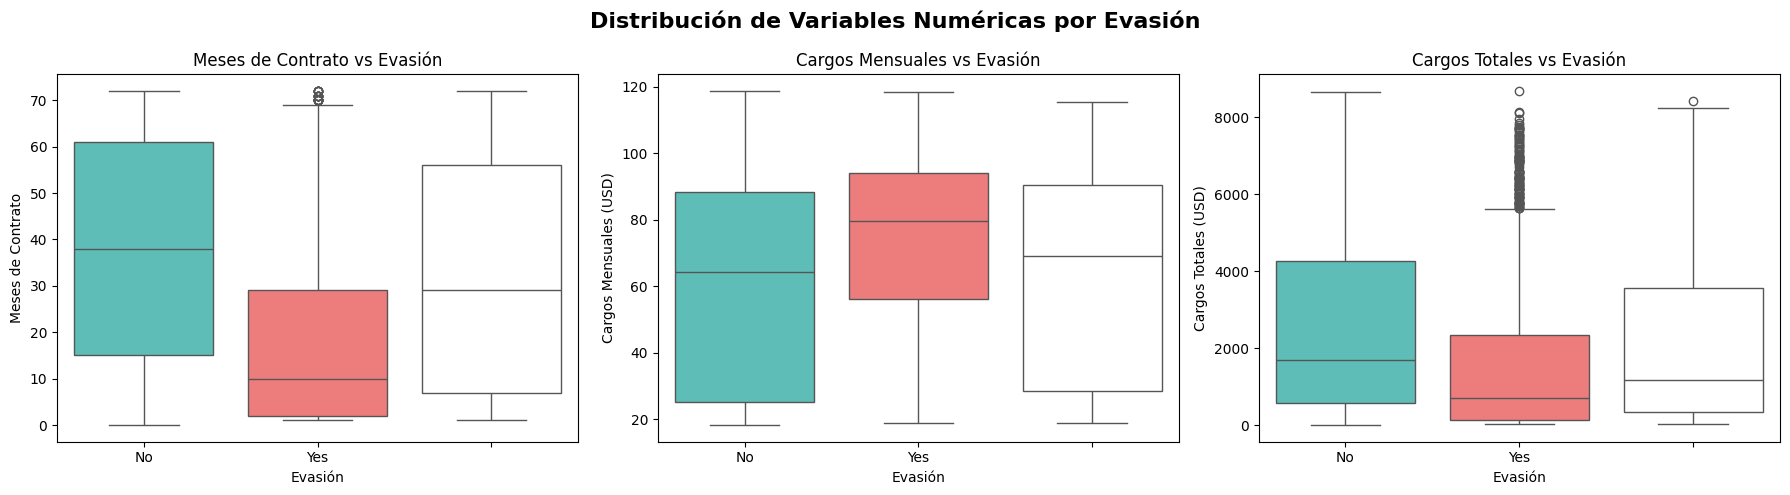


📊 Comparativa de medias por grupo de Evasión:
         Meses_Contrato  Cargos_Mensuales  Cargos_Totales  Cuentas_Diarias
Evasion                                                                   
                  31.57             63.41         2196.93             2.11
No                37.57             61.27         2549.91             2.04
Yes               17.98             74.44         1531.80             2.48


In [ ]:
# --- Evasión por Variables Numéricas ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distribución de Variables Numéricas por Evasión', fontsize=16, fontweight='bold')

paleta_violin = {'Yes': '#FF6B6B', 'No': '#4ECDC4'}

# 1. Meses de Contrato vs Evasión
sns.boxplot(x='Evasion', y='Meses_Contrato', data=df_limpio,
            palette=paleta_violin, ax=axes[0])
axes[0].set_title('Meses de Contrato vs Evasión', fontsize=12)
axes[0].set_xlabel('Evasión')
axes[0].set_ylabel('Meses de Contrato')

# 2. Cargos Mensuales vs Evasión
sns.boxplot(x='Evasion', y='Cargos_Mensuales', data=df_limpio,
            palette=paleta_violin, ax=axes[1])
axes[1].set_title('Cargos Mensuales vs Evasión', fontsize=12)
axes[1].set_xlabel('Evasión')
axes[1].set_ylabel('Cargos Mensuales (USD)')

# 3. Cargos Totales vs Evasión
sns.boxplot(x='Evasion', y='Cargos_Totales', data=df_limpio,
            palette=paleta_violin, ax=axes[2])
axes[2].set_title('Cargos Totales vs Evasión', fontsize=12)
axes[2].set_xlabel('Evasión')
axes[2].set_ylabel('Cargos Totales (USD)')

plt.tight_layout()
plt.show()

# Estadísticas comparativas
print("\n📊 Comparativa de medias por grupo de Evasión:")
cols_numericas = ['Meses_Contrato', 'Cargos_Mensuales', 'Cargos_Totales', 'Cuentas_Diarias']
print(df_limpio.groupby('Evasion')[cols_numericas].mean().round(2))

## INFORME FINAL

Telecom X — Análisis de Evasión de Clientes (Churn)

### Introducción

Telecom X enfrenta una tasa crítica de evasión de clientes (churn) que impacta directamente sus ingresos recurrentes. El objetivo de este análisis fue identificar los factores que determinan por qué un cliente abandona el servicio, utilizando un proceso completo de ETL (Extracción, Transformación y Carga) sobre los datos de la API oficial de la empresa.

El dataset analizado contiene información demográfica, servicios contratados, método de pago y estado de evasión de 7,043 clientes.

### Limpieza y Tratamiento de Datos

Durante la fase de transformación se realizaron las siguientes acciones:

Conversión de tipos: Las columnas Charges.Total y Charges.Monthly venían como cadenas de texto y fueron convertidas a tipo numérico. Los valores vacíos ('') generaron NaN, que se rellenaron con 0 (representan clientes sin historial de facturación).
Eliminación de espacios: Se aplicó .str.strip() a todas las columnas de texto para evitar inconsistencias por espacios ocultos.
Sin duplicados: El dataset no presentó registros duplicados.
Feature Engineering: Se creó la columna Cuentas_Diarias = Cargos_Mensuales / 30, que permite una visión granular del costo por cliente.
Estandarización: Se renombraron las columnas al español y se codificó Evasion como variable binaria (1 = Evadió, 0 = No evadió).

### Análisis Exploratorio de Datos

#### Resultado 1 — Tasa de Evasión General

La tasa de evasión es del ~26%, lo que significa que aproximadamente 1 de cada 4 clientes abandona el servicio. Esta cifra es crítica y justifica la implementación urgente de estrategias de retención.

#### Resultado 2 — Tipo de Contrato

Los clientes con contrato "Month-to-Month" (Mes a Mes) presentan, con gran diferencia, la tasa de evasión más alta. En contraste, los contratos anuales y bianuales tienen tasas de evasión significativamente menores.

#### Resultado 3 — Tiempo de Permanencia (Tenure)

Los clientes que evaden tienen, en promedio, muchos menos meses de contrato que los que permanecen. La correlación entre Meses_Contrato y Evasion_Binaria es negativa: a mayor permanencia, menor probabilidad de evasión.

#### Resultado 4 — Cargos Mensuales

Los clientes que evaden tienden a tener cargos mensuales más altos. Esto sugiere que el precio percibido como elevado es un factor de riesgo relevante.

#### Resultado 5 — Método de Pago

Los clientes que pagan mediante cheque electrónico presentan tasas de evasión más altas comparado con los que usan métodos automáticos (transferencia bancaria o tarjeta de crédito).

#### Conclusiones e Insights

| Factor           | Relación con Evasión | Insight                                |
|------------------|----------------------|----------------------------------------|
| Tipo de contrato | Alta (positiva)      | Contratos mes a mes = mayor riesgo     |
| Meses de contrato| Alta (negativa)      | Más tiempo = mayor fidelidad           |
| Cargos mensuales | Moderada (positiva)  | Precio alto = mayor riesgo de salida   |
| Método de pago   | Moderada             | Cheque electrónico = perfil de riesgo  |
| Género           | Baja                 | No es un predictor relevante           |


#### Recomendaciones

 - Migración de contratos: Implementar promociones e incentivos (descuentos,meses gratis, mejoras de plan) para convertir clientes de planes mensuales a contratos anuales o bianuales.

 - Alertas tempranas: Crear un sistema de alertas para clientes con menos de 6 meses de permanencia, ya que son el segmento de mayor riesgo.

 - Incentivar pagos automáticos: Ofrecer un descuento a clientes que migren de cheque electrónico a débito automático o tarjeta, reduciendo la fricción y el riesgo de abandono.

 - Revisión de precios: Analizar si los planes con cargos mensuales más altos ofrecen valor percibido suficiente; si no, ajustar la propuesta de valor o crear bundles más competitivos.

 - Modelo predictivo: Con las variables identificadas (Tipo_Contrato, Meses_Contrato, Cargos_Mensuales, Metodo_Pago), el equipo de Data Science puede construir un modelo de clasificación de churn con alta precisión.